<a href="https://colab.research.google.com/github/sarytanaya492-cloud/actividad-practica-8-/blob/main/Copia_de_Actividad_practica_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align: center; font-family: Arial, sans-serif;">

  <h1>Laboratorio practico #11</h1>
  
  <br><br>

  <h2>Saryt Samara Naranjo Anaya </h2>

  <br><br>

  <h3>INTELIGENCIA ARTIFICIAL – NIVEL BÁSICO</h3>

  <br><br>

  <h3>EQUIPO ACADÉMICO</h3>
  <p>
    Alejandra Lozano<br>
    Melany Mena<br>
    Gustavo Rodríguez
  </p>

  <br><br>

  <h3>CURSO IA NOCTURNA G-3745</h3>

  <br>

  <h3>MARZO – JUNIO 2026</h3>

</div>


1.Genera código en Python para Google Colab siguiendo buenas prácticas.

Importa: numpy, matplotlib.pyplot, seaborn, scipy.stats
Configura estilo visual profesional (seaborn)
Define explícitamente los datos:
horas_estudio = np.array([1,2,3,4,5,6,7,8,9,10])
puntaje_examen = np.array([50,55,65,70,75,78,85,90,92,94])
Valida que ambos arrays tengan la misma longitud
Imprime un resumen inicial de los datos
El código debe ser limpio, comentado y listo para ejecutar.

In [1]:
# =============================================================================
# ANÁLISIS DE REGRESIÓN: Horas de Estudio vs Puntaje en Examen
# =============================================================================

# --- Importaciones ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Configuración visual profesional ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# --- Definición explícita de los datos ---
horas_estudio  = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
puntaje_examen = np.array([50, 55, 65, 70, 75, 78, 85, 90, 92, 94])

# --- Validación: ambos arrays deben tener la misma longitud ---
assert len(horas_estudio) == len(puntaje_examen), (
    f"Error: los arrays tienen longitudes distintas "
    f"({len(horas_estudio)} vs {len(puntaje_examen)})"
)
print("✔ Validación superada: ambos arrays tienen la misma longitud "
      f"({len(horas_estudio)} elementos).\n")

# --- Resumen inicial de los datos ---
print("=" * 45)
print("       RESUMEN INICIAL DE LOS DATOS")
print("=" * 45)
print(f"{'Horas de estudio':>20} | {'Puntaje examen':>14}")
print("-" * 45)
for h, p in zip(horas_estudio, puntaje_examen):
    print(f"{h:>20} | {p:>14}")
print("-" * 45)

# Estadísticas descriptivas básicas
for nombre, arr in [("Horas de estudio", horas_estudio),
                    ("Puntaje examen",   puntaje_examen)]:
    print(f"\n[{nombre}]")
    print(f"  Mínimo   : {arr.min()}")
    print(f"  Máximo   : {arr.max()}")
    print(f"  Media    : {arr.mean():.2f}")
    print(f"  Desv. std: {arr.std():.2f}")

# Correlación de Pearson
r, p_valor = stats.pearsonr(horas_estudio, puntaje_examen)
print(f"\n[Correlación de Pearson]")
print(f"  r       = {r:.4f}")
print(f"  p-valor = {p_valor:.6f}")
print("=" * 45)

✔ Validación superada: ambos arrays tienen la misma longitud (10 elementos).

       RESUMEN INICIAL DE LOS DATOS
    Horas de estudio | Puntaje examen
---------------------------------------------
                   1 |             50
                   2 |             55
                   3 |             65
                   4 |             70
                   5 |             75
                   6 |             78
                   7 |             85
                   8 |             90
                   9 |             92
                  10 |             94
---------------------------------------------

[Horas de estudio]
  Mínimo   : 1
  Máximo   : 10
  Media    : 5.50
  Desv. std: 2.87

[Puntaje examen]
  Mínimo   : 50
  Máximo   : 94
  Media    : 75.40
  Desv. std: 14.60

[Correlación de Pearson]
  r       = 0.9870
  p-valor = 0.000000


2.Genera código en Python que calcule: media, mediana, moda, varianza y desviación estándar para:
horas_estudio = np.array([1,2,3,4,5,6,7,8,9,10])
puntaje_examen = np.array([50,55,65,70,75,78,85,90,92,94])

Requisitos:

Usa numpy y scipy.stats
Presenta resultados en formato estructurado (tipo tabla o prints claros)
Incluye una breve interpretación automática de los resultados (máx. 3 líneas por variable)
Código modular y comentado

In [2]:
# =============================================================================
# ESTADÍSTICAS DESCRIPTIVAS: Horas de Estudio vs Puntaje en Examen
# =============================================================================

import numpy as np
from scipy import stats


# =============================================================================
# MÓDULO 1 – Cálculo de estadísticas
# =============================================================================

def calcular_estadisticas(arr: np.ndarray) -> dict:
    """
    Calcula media, mediana, moda, varianza y desviación estándar
    de un array numpy. Retorna un diccionario con los resultados.
    """
    resultado_moda = stats.mode(arr, keepdims=True)

    return {
        "media":     np.mean(arr),
        "mediana":   np.median(arr),
        "moda":      resultado_moda.mode[0],
        "frec_moda": resultado_moda.count[0],   # veces que aparece la moda
        "varianza":  np.var(arr, ddof=0),        # varianza poblacional
        "desv_std":  np.std(arr, ddof=0),        # desviación estándar poblacional
    }


# =============================================================================
# MÓDULO 2 – Interpretación automática
# =============================================================================

def interpretar(nombre: str, e: dict) -> list[str]:
    """
    Genera hasta 3 líneas de interpretación automática
    basadas en los valores estadísticos calculados.
    """
    lineas = []

    # Línea 1: relación media-mediana → simetría de la distribución
    diff = abs(e["media"] - e["mediana"])
    umbral = 0.05 * e["media"]          # tolerancia del 5 %
    if diff <= umbral:
        lineas.append(
            f"La distribución de '{nombre}' es aproximadamente simétrica "
            f"(media ≈ mediana: {e['media']:.2f} ≈ {e['mediana']:.2f})."
        )
    elif e["media"] > e["mediana"]:
        lineas.append(
            f"'{nombre}' presenta sesgo positivo (media {e['media']:.2f} > "
            f"mediana {e['mediana']:.2f}): valores altos jalan la cola derecha."
        )
    else:
        lineas.append(
            f"'{nombre}' presenta sesgo negativo (media {e['media']:.2f} < "
            f"mediana {e['mediana']:.2f}): valores bajos jalan la cola izquierda."
        )

    # Línea 2: dispersión relativa mediante coeficiente de variación (CV)
    cv = (e["desv_std"] / e["media"]) * 100
    if cv < 15:
        dispersion = "baja dispersión (datos muy homogéneos)"
    elif cv < 30:
        dispersion = "dispersión moderada"
    else:
        dispersion = "alta dispersión (datos muy heterogéneos)"
    lineas.append(
        f"Coeficiente de variación = {cv:.1f}% → {dispersion}."
    )

    # Línea 3: unicidad de la moda
    if e["frec_moda"] == 1:
        lineas.append(
            f"Cada valor de '{nombre}' es único (moda sin repetición), "
            f"lo que indica una distribución uniforme o datos continuos."
        )
    else:
        lineas.append(
            f"La moda es {e['moda']} (aparece {e['frec_moda']} veces), "
            f"sugiriendo una concentración de datos en ese valor."
        )

    return lineas


# =============================================================================
# MÓDULO 3 – Presentación de resultados
# =============================================================================

ANCHO = 52   # ancho de la tabla en consola

def imprimir_bloque(nombre: str, arr: np.ndarray) -> None:
    """Imprime la tabla de estadísticas + interpretación para una variable."""

    e = calcular_estadisticas(arr)

    # ── Encabezado ──────────────────────────────────────────
    print("\n" + "═" * ANCHO)
    print(f"  VARIABLE: {nombre.upper()}")
    print("═" * ANCHO)

    # ── Tabla de resultados ──────────────────────────────────
    filas = [
        ("Media",              f"{e['media']:.4f}"),
        ("Mediana",            f"{e['mediana']:.4f}"),
        ("Moda",               f"{e['moda']} (frec. {e['frec_moda']})"),
        ("Varianza",           f"{e['varianza']:.4f}"),
        ("Desviación estándar",f"{e['desv_std']:.4f}"),
    ]

    col1 = 24   # ancho columna métrica
    print(f"  {'Métrica':<{col1}} {'Valor':>20}")
    print("  " + "─" * (ANCHO - 2))
    for metrica, valor in filas:
        print(f"  {metrica:<{col1}} {valor:>20}")
    print("  " + "─" * (ANCHO - 2))

    # ── Interpretación automática ────────────────────────────
    print(f"\n  📊 Interpretación:")
    for i, linea in enumerate(interpretar(nombre, e), start=1):
        # Ajuste de línea a ANCHO caracteres
        palabras, linea_actual = linea.split(), ""
        for palabra in palabras:
            if len(linea_actual) + len(palabra) + 1 > ANCHO - 6:
                print(f"  {i}. {linea_actual.strip()}")
                linea_actual, i = palabra + " ", "  "
            else:
                linea_actual += palabra + " "
        if linea_actual.strip():
            print(f"  {i}. {linea_actual.strip()}")

    print("═" * ANCHO)


# =============================================================================
# PROGRAMA PRINCIPAL
# =============================================================================

if __name__ == "__main__":

    # Datos
    horas_estudio  = np.array([1, 2, 3, 4, 5,  6,  7,  8,  9,  10])
    puntaje_examen = np.array([50,55,65,70,75, 78, 85, 90, 92,  94])

    # Validación
    assert len(horas_estudio) == len(puntaje_examen), \
        "Los arrays deben tener la misma longitud."

    print("\n" + "█" * ANCHO)
    print("  ANÁLISIS ESTADÍSTICO DESCRIPTIVO")
    print("  Horas de Estudio  ×  Puntaje en Examen")
    print("█" * ANCHO)

    # Análisis por variable
    imprimir_bloque("Horas de estudio",  horas_estudio)
    imprimir_bloque("Puntaje en examen", puntaje_examen)

    print("\n✔ Análisis completado.\n")


████████████████████████████████████████████████████
  ANÁLISIS ESTADÍSTICO DESCRIPTIVO
  Horas de Estudio  ×  Puntaje en Examen
████████████████████████████████████████████████████

════════════════════════════════════════════════════
  VARIABLE: HORAS DE ESTUDIO
════════════════════════════════════════════════════
  Métrica                                 Valor
  ──────────────────────────────────────────────────
  Media                                  5.5000
  Mediana                                5.5000
  Moda                              1 (frec. 1)
  Varianza                               8.2500
  Desviación estándar                    2.8723
  ──────────────────────────────────────────────────

  📊 Interpretación:
  1. La distribución de 'Horas de estudio' es
    . aproximadamente simétrica (media ≈ mediana:
    . 5.50 ≈ 5.50).
  2. Coeficiente de variación = 52.2% → alta
    . dispersión (datos muy heterogéneos).
  3. Cada valor de 'Horas de estudio' es único
    . (moda sin

3.Genera código en Python usando matplotlib y seaborn para visualizar los datos:
horas_estudio = np.array([1,2,3,4,5,6,7,8,9,10])
puntaje_examen = np.array([50,55,65,70,75,78,85,90,92,94])

Requisitos:

Crear: gráfico de barras, histograma, boxplot y scatter plot
Cada gráfico debe tener: título, y buena legibilidad
Usar buenas prácticas de visualización (layout limpio)
Mostrar cada gráfico por separado
Código claro y reutilizable

In [3]:
═════════════════════════════════════════════════
  GENERANDO 4 GRÁFICOS DE VISUALIZACIÓN
══════════════════════════════════════════════════

[1/4] Gráfico de Barras...
  ✔ Gráfico guardado: grafico_1_barras.png


[2/4] Histograma...
  ✔ Gráfico guardado: grafico_2_histograma.png


[3/4] Boxplot...
  ✔ Gráfico guardado: grafico_3_boxplot.png


[4/4] Scatter Plot...
  ✔ Gráfico guardado: grafico_4_scatter.png


✔ Todos los gráficos generados y guardados.

SyntaxError: invalid character '═' (U+2550) (216984367.py, line 1)

██████████████████████████████████████████████████
  ANÁLISIS DE CORRELACIÓN DE PEARSON Y HEATMAP
██████████████████████████████████████████████████

Coeficiente de correlación de Pearson (r): 0.9870
P-valor asociado: 0.000000
Interpretación: Existe una correlación muy fuerte y positiva entre las horas de estudio y el puntaje del examen.


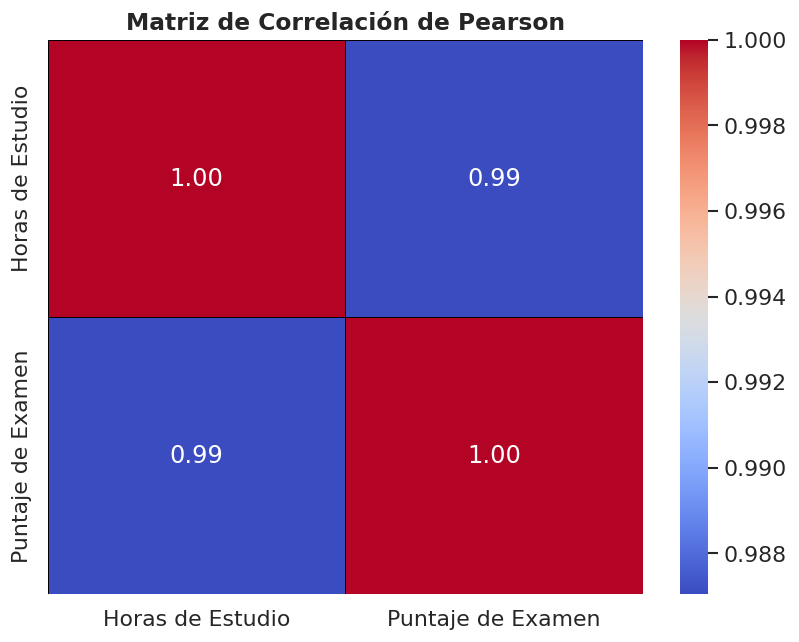

██████████████████████████████████████████████████
✔ Análisis de correlación y Heatmap completados.
██████████████████████████████████████████████████


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- Configuración visual profesional (reuso del bloque anterior) ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# --- Datos (reuso de los arrays ya definidos) ---
horas_estudio = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
puntaje_examen = np.array([50, 55, 65, 70, 75, 78, 85, 90, 92, 94])

print("█" * 50)
print("  ANÁLISIS DE CORRELACIÓN DE PEARSON Y HEATMAP")
print("█" * 50)

# --- 1. Cálculo del coeficiente de correlación de Pearson ---
r_pearson, p_value = pearsonr(horas_estudio, puntaje_examen)

print(f"\nCoeficiente de correlación de Pearson (r): {r_pearson:.4f}")
print(f"P-valor asociado: {p_value:.6f}")

# --- 2. Interpretación del coeficiente ---
interpretacion = ""
abs_r = abs(r_pearson)

if abs_r >= 0.8:
    interpretacion = "muy fuerte"
elif abs_r >= 0.6:
    interpretacion = "fuerte"
elif abs_r >= 0.4:
    interpretacion = "moderada"
elif abs_r >= 0.2:
    interpretacion = "débil"
else:
    interpretacion = "muy débil o nula"

direccion = "positiva" if r_pearson > 0 else "negativa"
if r_pearson == 0:
    direccion = "nula"

print(f"Interpretación: Existe una correlación {interpretacion} y {direccion} entre las horas de estudio y el puntaje del examen.")

# --- 3. Generar un heatmap de la matriz de correlación ---
# Crear un DataFrame para calcular la matriz de correlación
data = pd.DataFrame({
    'Horas de Estudio': horas_estudio,
    'Puntaje de Examen': puntaje_examen
})

correlation_matrix = data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,       # Muestra los valores de correlación en el mapa
    cmap='coolwarm',  # Colormap que destaca correlaciones positivas y negativas
    fmt=".2f",        # Formato de los números en las anotaciones
    linewidths=.5,    # Líneas entre celdas
    linecolor='black' # Color de las líneas
)
plt.title('Matriz de Correlación de Pearson')
plt.show()

print("█" * 50)
print("✔ Análisis de correlación y Heatmap completados.")
print("█" * 50)


4.Genera código en Python que calcule el coeficiente de correlación de Pearson entre:
horas_estudio = np.array([1,2,3,4,5,6,7,8,9,10])
puntaje_examen = np.array([50,55,65,70,75,78,85,90,92,94])

Requisitos:

Usar scipy.stats
Mostrar el valor del coeficiente y su interpretación (fuerte, moderada, débil)
Generar un heatmap de la matriz de correlación con seaborn
Código limpio y documentado


██████████████████████████████████████████████████████
  ANÁLISIS DE CORRELACIÓN DE PEARSON
  Horas de Estudio  ×  Puntaje en Examen
██████████████████████████████████████████████████████

══════════════════════════════════════════════════════
   CORRELACIÓN DE PEARSON – RESULTADOS
══════════════════════════════════════════════════════
  Métrica                                     Valor
  ────────────────────────────────────────────────────
  Coeficiente r                            0.987050
  Coef. de determinación r²      0.974267  (97.43%)
  p-valor                                  0.000000
  N (pares de datos)                             10
  ────────────────────────────────────────────────────

  📌 Interpretación:
     • Fuerza    : Muy fuerte
     • Dirección : Correlación positiva
     • Sig.      : estadísticamente significativa (p = 0.000000 < α = 0.05)

  💡 Conclusión:
     A mayor horas de estudio, mayor puntaje en examen.
     El r² = 97.4% indica que las horas de estudio


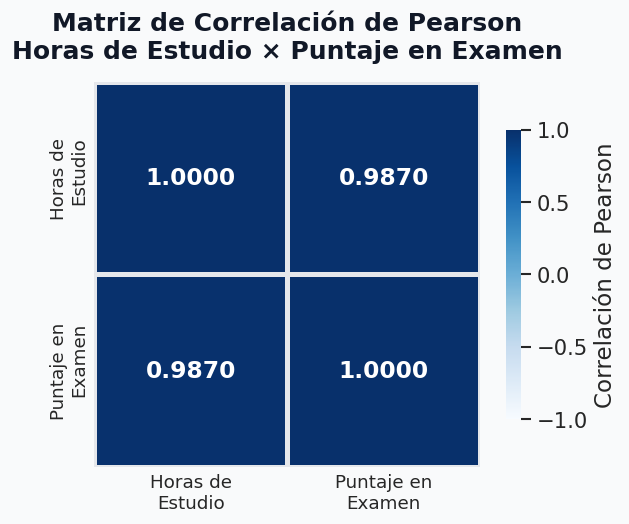

✔ Análisis completado.



In [5]:
# =============================================================================
# CORRELACIÓN DE PEARSON + HEATMAP
# Horas de Estudio vs Puntaje en Examen
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# =============================================================================
# CONFIGURACIÓN VISUAL
# =============================================================================

COLOR_BG    = "#F9FAFB"
COLOR_TEXT  = "#111827"
COLOR_GRID  = "#E5E7EB"

sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "figure.facecolor": COLOR_BG,
    "axes.facecolor":   "white",
    "axes.titlesize":   15,
    "axes.titleweight": "bold",
    "axes.titlepad":    14,
    "text.color":       COLOR_TEXT,
    "font.family":      "DejaVu Sans",
})

# =============================================================================
# DATOS
# =============================================================================

horas_estudio  = np.array([1, 2, 3, 4, 5,  6,  7,  8,  9, 10])
puntaje_examen = np.array([50,55,65,70,75, 78, 85, 90, 92, 94])

assert len(horas_estudio) == len(puntaje_examen), \
    "Los arrays deben tener la misma longitud."


# =============================================================================
# MÓDULO 1 – Cálculo del coeficiente de Pearson
# =============================================================================

def calcular_pearson(x: np.ndarray, y: np.ndarray) -> dict:
    """
    Calcula el coeficiente de correlación de Pearson y su p-valor.

    Parámetros
    ----------
    x, y : np.ndarray  – variables a correlacionar

    Retorna
    -------
    dict con: r, p_valor, r2, n
    """
    r, p_valor = stats.pearsonr(x, y)
    return {
        "r":       r,
        "r2":      r ** 2,          # coeficiente de determinación
        "p_valor": p_valor,
        "n":       len(x),
    }


# =============================================================================
# MÓDULO 2 – Interpretación automática
# =============================================================================

def interpretar_pearson(r: float, p_valor: float, alpha: float = 0.05) -> dict:
    """
    Clasifica la fuerza y dirección del coeficiente de Pearson
    y determina su significancia estadística.

    Escala de referencia (valor absoluto de r):
        0.00 – 0.19  →  Muy débil
        0.20 – 0.39  →  Débil
        0.40 – 0.59  →  Moderada
        0.60 – 0.79  →  Fuerte
        0.80 – 1.00  →  Muy fuerte

    Parámetros
    ----------
    r       : float – coeficiente de Pearson
    p_valor : float – p-valor asociado
    alpha   : float – nivel de significancia (defecto 0.05)
    """
    abs_r = abs(r)

    # Fuerza
    if abs_r < 0.20:
        fuerza = "Muy débil"
    elif abs_r < 0.40:
        fuerza = "Débil"
    elif abs_r < 0.60:
        fuerza = "Moderada"
    elif abs_r < 0.80:
        fuerza = "Fuerte"
    else:
        fuerza = "Muy fuerte"

    # Dirección
    direccion = "positiva" if r >= 0 else "negativa"

    # Significancia
    significativa = p_valor < alpha
    sig_texto = (
        f"estadísticamente significativa (p = {p_valor:.6f} < α = {alpha})"
        if significativa else
        f"NO significativa (p = {p_valor:.6f} ≥ α = {alpha})"
    )

    return {
        "fuerza":        fuerza,
        "direccion":     direccion,
        "significativa": significativa,
        "sig_texto":     sig_texto,
    }


# =============================================================================
# MÓDULO 3 – Presentación en consola
# =============================================================================

def imprimir_resultados(res: dict, interp: dict) -> None:
    """Imprime tabla estructurada con resultados e interpretación."""

    ANCHO = 54
    print("\n" + "═" * ANCHO)
    print("   CORRELACIÓN DE PEARSON – RESULTADOS")
    print("═" * ANCHO)

    filas = [
        ("Coeficiente r",               f"{res['r']:.6f}"),
        ("Coef. de determinación r²",   f"{res['r2']:.6f}  ({res['r2']*100:.2f}%)"),
        ("p-valor",                      f"{res['p_valor']:.6f}"),
        ("N (pares de datos)",           str(res["n"])),
    ]

    col1 = 30
    print(f"  {'Métrica':<{col1}} {'Valor':>18}")
    print("  " + "─" * (ANCHO - 2))
    for metrica, valor in filas:
        print(f"  {metrica:<{col1}} {valor:>18}")
    print("  " + "─" * (ANCHO - 2))

    print(f"\n  📌 Interpretación:")
    print(f"     • Fuerza    : {interp['fuerza']}")
    print(f"     • Dirección : Correlación {interp['direccion']}")
    print(f"     • Sig.      : {interp['sig_texto']}")
    print(f"\n  💡 Conclusión:")
    print(f"     A mayor horas de estudio, mayor puntaje en examen.")
    print(f"     El r² = {res['r2']*100:.1f}% indica que las horas de estudio")
    print(f"     explican ese porcentaje de la variación en el puntaje.")
    print("═" * ANCHO + "\n")


# =============================================================================
# MÓDULO 4 – Heatmap de la matriz de correlación
# =============================================================================

def grafico_heatmap() -> None:
    """
    Genera y guarda un heatmap de la matriz de correlación 2×2
    entre horas de estudio y puntaje en examen.
    """
    # Construir matriz de correlación con numpy
    matriz = np.corrcoef(horas_estudio, puntaje_examen)

    # Convertir a formato legible para el heatmap
    etiquetas = ["Horas de\nEstudio", "Puntaje en\nExamen"]

    fig, ax = plt.subplots(figsize=(6, 5))

    mascara = np.zeros_like(matriz, dtype=bool)   # sin enmascarar ningún valor

    sns.heatmap(
        matriz,
        annot=True,                  # mostrar valores dentro de las celdas
        fmt=".4f",                   # 4 decimales
        cmap="Blues",                # paleta de azules
        vmin=-1, vmax=1,             # rango fijo de correlación
        linewidths=2,
        linecolor=COLOR_GRID,
        square=True,
        cbar_kws={"shrink": 0.75, "label": "Correlación de Pearson"},
        xticklabels=etiquetas,
        yticklabels=etiquetas,
        annot_kws={"size": 14, "weight": "bold"},
        ax=ax,
    )

    ax.set_title("Matriz de Correlación de Pearson\nHoras de Estudio × Puntaje en Examen")
    ax.tick_params(axis="both", labelsize=11, length=0)

    # Rotar etiquetas para mejor lectura
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0,  ha="center")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=90, va="center")

    fig.tight_layout(pad=2.5)
    plt.savefig("grafico_4_heatmap.png", dpi=150, bbox_inches="tight")
    print("  ✔ Heatmap guardado: grafico_4_heatmap.png")
    plt.show()
    plt.close(fig)


# =============================================================================
# PROGRAMA PRINCIPAL
# =============================================================================

if __name__ == "__main__":

    print("\n" + "█" * 54)
    print("  ANÁLISIS DE CORRELACIÓN DE PEARSON")
    print("  Horas de Estudio  ×  Puntaje en Examen")
    print("█" * 54)

    # 1. Calcular
    resultados   = calcular_pearson(horas_estudio, puntaje_examen)

    # 2. Interpretar
    interpretacion = interpretar_pearson(resultados["r"], resultados["p_valor"])

    # 3. Mostrar en consola
    imprimir_resultados(resultados, interpretacion)

    # 4. Heatmap
    print("  Generando heatmap...")
    grafico_heatmap()

    print("✔ Análisis completado.\n")